In [1]:
# Lab 3: EEG Signal Analysis - Spectrogram and Wavelet

# =============================
!pip install --upgrade pip wheel setuptools
!pip install --no-cache-dir PyWavelets

In [2]:
# Lab 3: EEG Signal Analysis - Spectrogram and Wavelet

# =============================
# 1. Import Libraries
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import pywt

In [3]:
# 下载 EEG EDF 文件
!wget -O eeg18.edf "https://zenodo.org/records/2547147/files/eeg18.edf?download=1"


--2026-05-11 20:42:22--  https://zenodo.org/records/2547147/files/eeg18.edf?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 39261184 (37M) [application/octet-stream]
Saving to: ‘eeg18.edf’

eeg18.edf           100%[===================>]  37.44M  12.6MB/s    in 3.0s    

2026-05-11 20:42:25 (12.6 MB/s) - ‘eeg18.edf’ saved [39261184/39261184]



In [4]:
raw = mne.io.read_raw_edf('eeg18.edf', preload=True)
data, times = raw.get_data(), raw.times
sfreq = raw.info['sfreq']


# Print basic info
print(raw.info)
print('Data shape:', data.shape)

Extracting EDF parameters from eeg18.edf...
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_16785/2856559129.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf('eeg18.edf', preload=True)
/tmp/ipykernel_16785/2856559129.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf('eeg18.edf', preload=True)


Reading 0 ... 934655  =      0.000 ...  3650.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-Ref, EEG Fp2-Ref, EEG F3-Ref, EEG F4-Ref, EEG F7-Ref, ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 1.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2011-11-11 11:11:11 UTC
 nchan: 21
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>
Data shape: (21, 934656)


In [6]:
annotations = raw.annotations
print('Annotations:', annotations)


# Find seizure events (example, modify as needed)
seizure_idx = [i for i, desc in enumerate(annotations.description) if 'Seizure' in desc]
if seizure_idx:
  onset = annotations.onset[seizure_idx[0]]
  duration = annotations.duration[seizure_idx[0]]
  print(f'Seizure onset: {onset}s, duration: {duration}s')
  idx_start = int(onset * sfreq)
  idx_end = int((onset + duration) * sfreq)
else:
  print('No seizure event found, using first 10s')
  idx_start = 0
  idx_end = int(10 * sfreq)

Annotations: <Annotations | 0 segments>
No seizure event found, using first 10s


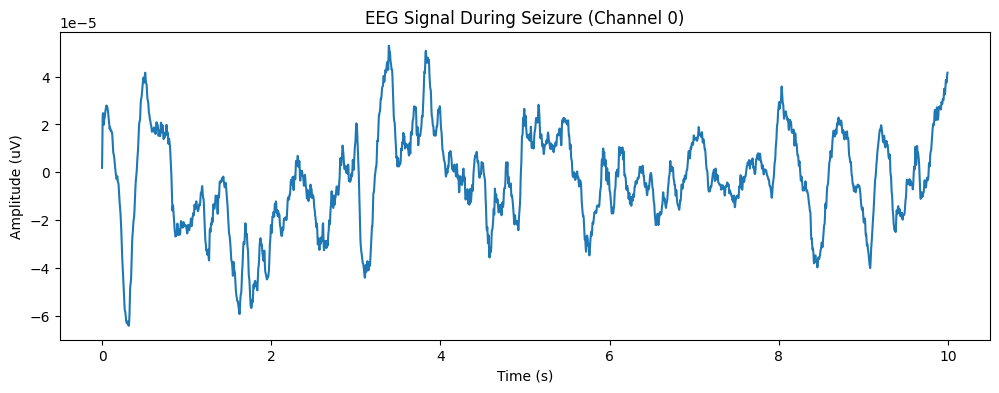

In [7]:
plt.figure(figsize=(12,4))
plt.plot(times[idx_start:idx_end], data[0, idx_start:idx_end])
plt.title('EEG Signal During Seizure (Channel 0)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.show()

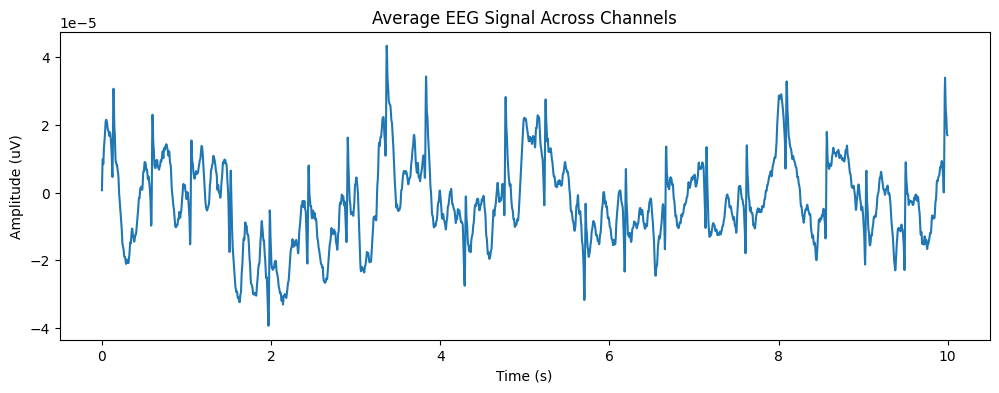

In [8]:
avg_signal = data[:, idx_start:idx_end].mean(axis=0)
plt.figure(figsize=(12,4))
plt.plot(times[idx_start:idx_end], avg_signal)
plt.title('Average EEG Signal Across Channels')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.show()

Setting up low-pass filter at 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 57 samples (0.223 s)



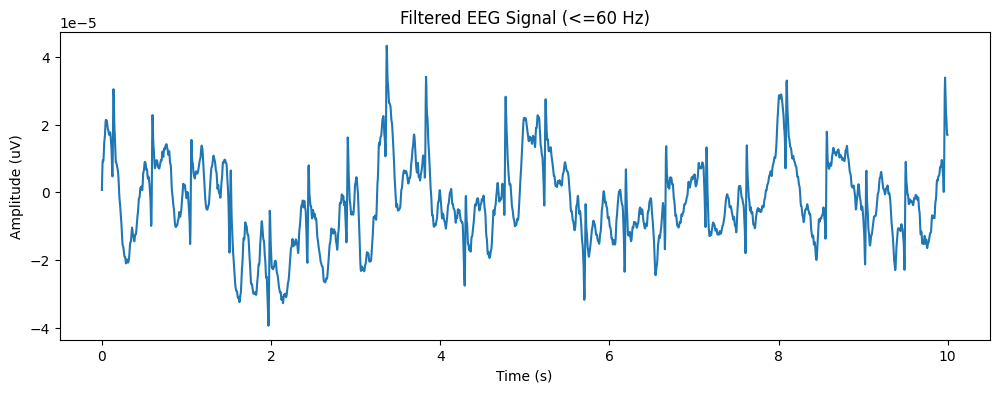

In [9]:
filtered = mne.filter.filter_data(avg_signal, sfreq=sfreq, l_freq=None, h_freq=60)
plt.figure(figsize=(12,4))
plt.plot(times[idx_start:idx_end], filtered)
plt.title('Filtered EEG Signal (<=60 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.show()

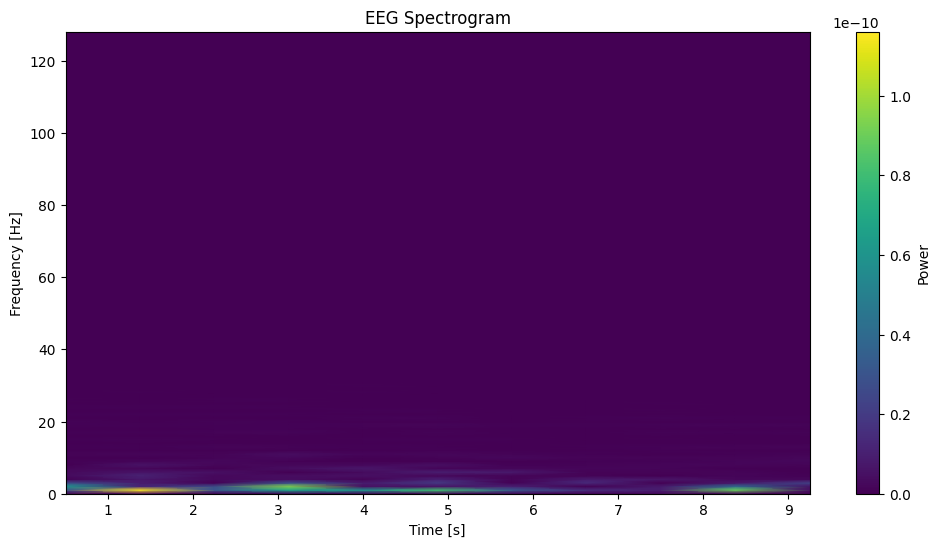

In [10]:
f, t, Sxx = spectrogram(filtered, fs=sfreq)
plt.figure(figsize=(12,6))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('EEG Spectrogram')
plt.colorbar(label='Power')
plt.show()

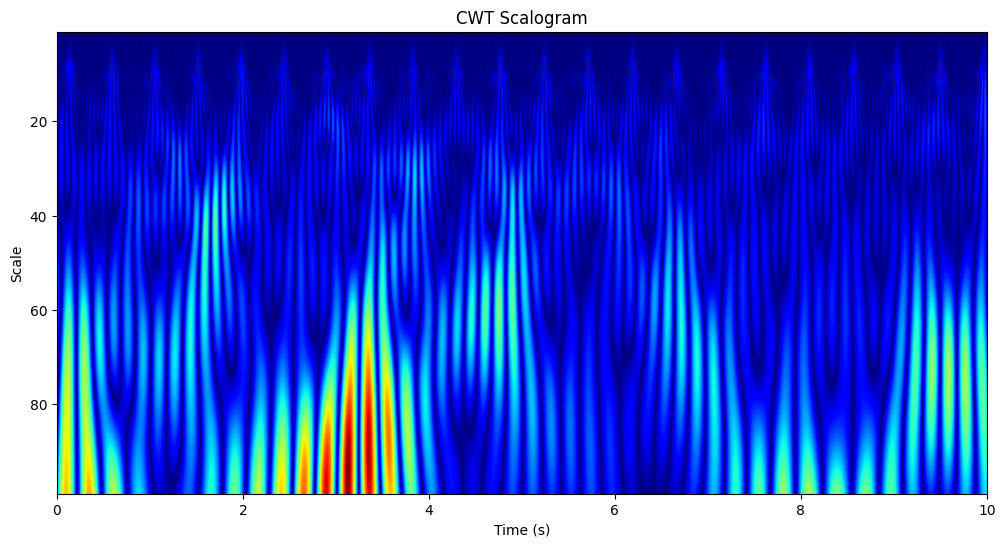

In [11]:
widths = np.arange(1, 100)
cwtmatr, freqs = pywt.cwt(filtered, widths, 'morl', sampling_period=1/sfreq)
plt.figure(figsize=(12,6))
plt.imshow(np.abs(cwtmatr), extent=[0, len(filtered)/sfreq, widths[-1], widths[0]],
cmap='jet', aspect='auto')
plt.title('CWT Scalogram')
plt.ylabel('Scale')
plt.xlabel('Time (s)')
plt.show()